In [ ]:
import os
import time
import django
import pandas as pd
from apps.core.services import obtener_vistas_youtube

df = pd.read_csv("micro_universo_artistas.csv")

os.environ.setdefault('DJANGO_SETTINGS_MODULE', 'TicketAPI_Poncho.settings')
django.setup()

for artista in df['artista'].values:
    vistas = obtener_vistas_youtube(artista)

    if vistas is not None:
        df.loc[df['artista'] == artista, ['reproducciones']] = vistas
    else: 
        print(f"no se encuentra el canal: {artista}")
    time.sleep(0.5)

,artista,reproducciones
27,LaKonga,4995375098
30,qlokuraok,4024970652
10,Karina,3420336300
9,Ke Personajes,3284242937
2,Luciano Pereyra,3191195181
15,Nicki Nicole,2388476311
8,Luck Ra,2228730954


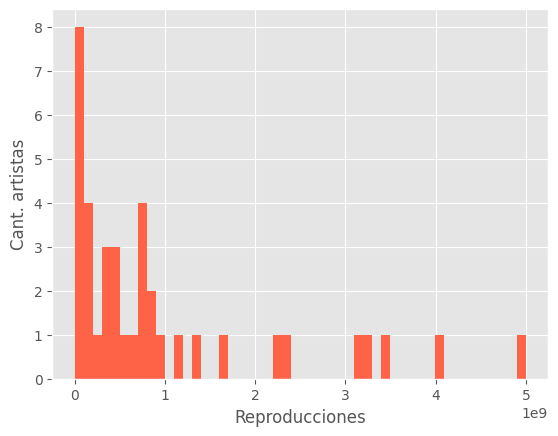

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rankdata
plt.style.use('ggplot')

df = pd.read_csv("micro_universo_artistas.csv")

valores = plt.hist(df['reproducciones'], bins= 50, color= 'tomato')
plt.xlabel('Reproducciones')
plt.ylabel('Cant. artistas')

df.nlargest(7, 'reproducciones')

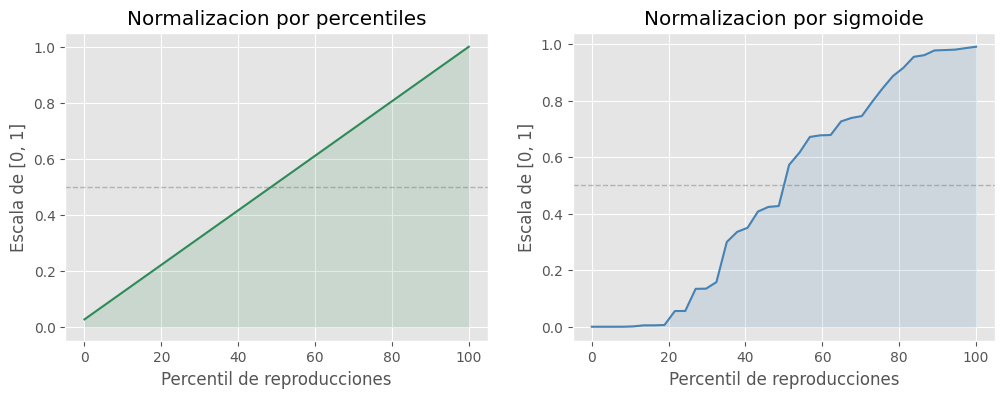

In [2]:
def percentil_rank(x):
    return rankdata(x, method='average') / len(x)

def log_sigmoide(x, k=6):
    log_x = np.log(x + 1) 
    mu = np.median(log_x) 
    sigma = log_x.std()
    z = k * (log_x - mu) / sigma 
    return 1 / (1 + np.exp(-z))


df['idx_percentil'] = percentil_rank(df['reproducciones'].values)
df['idx_sigmoide'] = log_sigmoide(df['reproducciones'].values) 

fig, axes = plt.subplots(1, 2, figsize= (12, 4))

percentil = df.sort_values('reproducciones')['idx_percentil'].values
axes[0].plot(np.linspace(0, 100, len(percentil)), percentil, color= 'seagreen')
axes[0].set_title('Normalizacion por percentiles')
axes[0].set_xlabel('Percentil de reproducciones')
axes[0].set_ylabel('Escala de [0, 1]')
axes[0].axhline(0.5, color= 'gray', lw= 1, ls= '--', alpha= 0.5)
axes[0].fill_between(np.linspace(0, 100, len(percentil)), percentil, alpha= 0.15, color= 'seagreen')

sigmoide = df.sort_values('reproducciones')['idx_sigmoide'].values
axes[1].plot(np.linspace(0, 100, len(sigmoide)), sigmoide, color= 'steelblue')
axes[1].set_title('Normalizacion por sigmoide')
axes[1].set_xlabel('Percentil de reproducciones')
axes[1].set_ylabel('Escala de [0, 1]')
axes[1].axhline(0.5, color= 'gray', lw= 1, ls= '--', alpha= 0.5)
axes[1].fill_between(np.linspace(0, 100, len(sigmoide)), sigmoide, alpha= 0.15, color= 'steelblue')


**Resultados:** 
- El ganador indiscutido con datos realistas es la normalizacion por sigmoide.
- No castiga los artistas pequeños pero tampoco premia de igual forma un artista medio-bajo como premia los artistas top